In [15]:
import sys
python_path = "/data/agapi_workspace/gnn-learning-engine-ar-explain"
if python_path not in sys.path:
    sys.path.insert(0, python_path)
print("Current Python Executable: ", sys.executable)
print("Current sys.path: ", sys.path)

import src
print("Imported src module from: ", src.__file__)

# Set the python path
import os
python_path = "/data/agapi_workspace/gnn-learning-engine-ar-explain/src"
env = os.environ.copy()
env["PYTHONPATH"] = python_path
print("PYTHONPATH set to:", env["PYTHONPATH"])

/home/ubuntu/anaconda3/envs/pyg_env_ar_explain/bin/python
['.', '/home/ubuntu/anaconda3/envs/pyg_env_ar_explain/lib/python311.zip', '/home/ubuntu/anaconda3/envs/pyg_env_ar_explain/lib/python3.11', '/home/ubuntu/anaconda3/envs/pyg_env_ar_explain/lib/python3.11/lib-dynload', '', '/home/ubuntu/anaconda3/envs/pyg_env_ar_explain/lib/python3.11/site-packages', '__editable__.gnn_rai-0.1.finder.__path_hook__', '/home/ubuntu/anaconda3/envs/pyg_env_ar_explain/lib/python3.11/site-packages/setuptools/_vendor', '/tmp/tmpxop2la6a']
/data/agapi_workspace/gnn-learning-engine-ar-explain/src/__init__.py


# Synthetic R-S Generation

### Toy Example: T-R-S database, count-based tasks

Specifically, add a table of intermediate reviews that are correlated with the outcome
* R(rid, x1, ..., xn, ylabel), S(sid, rid, x1, ..., xm), T(sid, rid, x1, ..., xk)
* Task 1 
y=true if 2 <=
(SELECT count(tid) FROM S WHERE S.rid = R.rid AND X_Boolean = True)
* Task 2
y=true if 4 <=
(SELECT count(tid) FROM S WHERE S.rid = R.rid)

In [16]:
# Make synthetic T-R-S dataset and count-based tasks
import os
import numpy as np
import pandas as pd

# Parameters
seed = 42
np.random.seed(seed)
n, m, k = 10, 5, 5  # number of features in R, S, T
num_r = 1000    # number of rows in R
num_s = 4000    # number of rows in S
num_t = 5000    # number of rows in T

# Table R: rid, x1..xn
R = pd.DataFrame({
    "rid": range(1, num_r + 1),
    **{f"x{i+1}": np.random.randn(num_r) for i in range(n)},
})

# Table S: sid, rid (foreign key to R), x1..xm, X_Boolean (for Task 1)
S = pd.DataFrame({
    "sid": range(1, num_s + 1),
    "rid": np.random.choice(R["rid"], num_s),
    **{f"x{i+1}": np.random.randn(num_s) for i in range(m)},
    "X_Boolean": np.random.choice([1, 0], num_s)
})

# Table T: sid, rid (foreign key to R), x1..xk
T = pd.DataFrame({
    "tid": range(1, num_t + 1),
    "rid": np.random.choice(R["rid"], num_t),
    **{f"x{i+1}": np.random.randn(num_t) for i in range(k)},
})


# -------------------------
# 2. Task 1: y = True if count(X_Boolean=True for S.rid=R.rid) >= 2
# -------------------------

count_true = (
    S[S["X_Boolean"] == True]
    .groupby("rid")["sid"]
    .count()
    .reindex(R["rid"], fill_value=0)
)
R_task1 = R.copy()
R_task1["label"] = count_true.values >= 2
R_task1 = R_task1[["rid", "label"]]

# -------------------------
# 3. Task 2: y = True if count(S.rid=R.rid) >= 4
# -------------------------

count_total = (
    S.groupby("rid")["sid"]
    .count()
    .reindex(R["rid"], fill_value=0)
)
R_task2 = R.copy()
R_task2["label"] = count_total.values >= 4
R_task2 = R_task2[["rid", "label"]]

# how many per class for each task?
print(f'Task 1 class distribution:\n{R_task1["label"].value_counts()}')
print(f'Task 2 class distribution:\n{R_task2["label"].value_counts()}')

# save dataset to disk
os.makedirs('/workspace/benchmark_datasets/r-s-synthetic/tasks/count-1', exist_ok=True)
os.makedirs('/workspace/benchmark_datasets/r-s-synthetic/tasks/count-2', exist_ok=True)
os.makedirs('/workspace/benchmark_datasets/r-s-synthetic/db', exist_ok=True)
R.to_parquet('/workspace/benchmark_datasets/r-s-synthetic/db/R.parquet', index=False)
S.to_parquet('/workspace/benchmark_datasets/r-s-synthetic/db/S.parquet', index=False)
T.to_parquet('/workspace/benchmark_datasets/r-s-synthetic/db/T.parquet', index=False)

# break into train/val/test splits (70/15/15)
for task in [1, 2]:
    if task == 1:
        R_task = R_task1
    else:
        R_task = R_task2
    # shuffle
    R_task = R_task.sample(frac=1, random_state=seed).reset_index(drop=True)
    num_examples = len(R_task)
    num_train = int(0.7 * num_examples)
    num_val = int(0.15 * num_examples)
    num_test = num_examples - num_train - num_val
    R_task_train = R_task.iloc[:num_train]
    R_task_val = R_task.iloc[num_train:num_train + num_val]
    R_task_test = R_task.iloc[num_train + num_val:]
    # save to disk
    R_task_train.to_parquet(f'/workspace/benchmark_datasets/r-s-synthetic/tasks/count-{task}/train.parquet', index=False)
    R_task_val.to_parquet(f'/workspace/benchmark_datasets/r-s-synthetic/tasks/count-{task}/val.parquet', index=False)
    R_task_test.to_parquet(f'/workspace/benchmark_datasets/r-s-synthetic/tasks/count-{task}/test.parquet', index=False)

Task 1 class distribution:
label
True     603
False    397
Name: count, dtype: int64
Task 2 class distribution:
label
True     559
False    441
Name: count, dtype: int64


# Synthetic R-S Case Study

In [17]:
import os
import copy
import json
from typing import Any, Dict, Optional, Tuple, Union

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot as plt

# Engine imports
from src.utils.utils import fix_all_seeds, timer
from src.explain.explainer import RDLExplainer
from src.load_utils import load_config, load_dataset_and_task, construct_graph, load_model

# the above imports use safelogger, I want to disable it for this script
# e.g., I get the following 2025-10-17 21:57:59,692 - SafeLogger - INFO - Loading model configuration... bellow
# i don't want that
import logging
logging.getLogger("SafeLogger").disabled = True
logging.getLogger("task_registry").disabled = True
logging.getLogger("gnn_app").disabled = True
logging.getLogger("sentence_transformers.SentenceTransformer").disabled = True
logging.getLogger("torch_frame.utils.io").disabled = True

# Suppress warnings from PyTorch about weights loading
# /workspace/miniconda3/envs/pyg_env/lib/python3.11/site-packages/torch_frame/utils/io.py:113: UserWarning: Weights only load failed. Please file an issue to make `torch.load(weights_only=True)` compatible in your case. Please use `torch.serialization.add_safe_globals([scalar])` to allowlist this global.
#   warnings.warn(f"{warn_msg} Please use "
import warnings
warnings.filterwarnings(
    "ignore",
    message="Weights only load failed. Please file an issue to make `torch.load\\(weights_only=True\\)` compatible.*"
)

In [18]:
task_name = 'count-2'

if task_name == 'count-1':
    root_dir = './eval_local/results_case_study/data/r-s-synthetic-count-1'
elif task_name == 'count-2':
    root_dir = './eval_local/results_case_study/data/r-s-synthetic-count-2'

data_config_path = os.path.join(root_dir, 'data_config.yaml')
model_config_path = os.path.join(root_dir, 'model_config.yaml')
model_params_path = os.path.join(root_dir, 'model.pth')

In [19]:
# Load configuration
model_config = load_config(model_config_path)
device = model_config.training_parameters.device

# Load dataset and task
dataset, task, task_parser = load_dataset_and_task(data_config_path) 
task_type = task.task_type
dataset_name = task.dataset.dataset_name
task_name = task.task_name
print(f'Dataset name: {dataset_name}. Task name: {task_name}. Task type: {task_type}.')

# Construct graph data
data, col_stats_dict = construct_graph(model_config, dataset)

# Load model, from saved state dict
model_to_explain = load_model(model_config, model_params_path, construct=True, data=data, col_stats_dict=col_stats_dict, task=task)

Task type: binary_classification


In [20]:
# Prepare explanation task, using soft targets
explanation_task = copy.deepcopy(task)
explanation_task.explanation_target_type = 'soft'
explanation_task.explanation_target_column = 'predictions'
explanation_task.explanation_soft_target_column = 'processed_output'
explanation_task.target_col = explanation_task.explanation_soft_target_column if explanation_task.explanation_target_type == 'soft' else explanation_task.explanation_target_column
prediction_col = 'predictions'
ground_truth_col = 'targets'

if task_name == 'count-1':
      explanation_table = pd.read_parquet(f'./eval_local/results_case_study/inference/r-s-synthetic-count-1/predictions_test.parquet')
elif task_name == 'count-2':
      explanation_table = pd.read_parquet(f'./eval_local/results_case_study/inference/r-s-synthetic-count-2/predictions_test.parquet')
      
explanation_task.train_table.df = explanation_table
explanation_task.val_table.df = explanation_table
explanation_task.test_table.df = explanation_table
print(f'Prepared explanation task with {len(explanation_task.train_table.df)} training samples, '
      f'{len(explanation_task.val_table.df)} validation samples, and {len(explanation_task.test_table.df)} test samples.')

Prepared explanation task with 150 training samples, 150 validation samples, and 150 test samples.


In [21]:
explanation_table

,rid,label,output,processed_output,predictions,rid_mapped
0,32,True,2.250762,0.904716,True,33
1,779,False,-2.371457,0.085375,False,780
2,839,False,-2.281773,0.092644,False,840
3,200,True,2.260644,0.905565,True,201
4,134,True,2.212449,0.901362,True,135
...,...,...,...,...,...,...
145,106,True,2.192343,0.899560,True,107
146,270,True,2.216450,0.901717,True,271
147,860,True,2.350117,0.912944,True,861
148,435,False,-2.301278,0.091017,False,436


In [22]:
roc_auc = roc_auc_score(explanation_table['label'], explanation_table['processed_output'])
print(f'Original ROC-AUC on explanation task data: {roc_auc}')

Original ROC-AUC on explanation task data: 1.0


In [23]:
# Initialize the explainer
explainer = RDLExplainer(model_config, model_to_explain, data, explanation_task)

In [24]:
# Learn masks
mask_types = ['column', 'fkpk']
masks_all = {}
metrics_all = {}

for mask_type in mask_types:
    print(f'Learning mask of type: {mask_type}')
    mask_learning_config = {'reg_eps': 0.01, 'learning_rate': 0.05, 'epochs': 250}
    if mask_type == 'column':
        mask_learning_config['explanation_type'] = 'column'
        mask_learning_config['elimination_strategy'] = 'permutation_joint'
    elif mask_type == 'fkpk':
        mask_learning_config['explanation_type'] = 'fkpk'
        mask_learning_config['elimination_strategy'] = 'zero'
    mask, mask_vals, metrics = explainer.learn_masks(
                                            eps = mask_learning_config['reg_eps'],
                                            explanation_type = mask_learning_config['explanation_type'], 
                                            elimination_strategy = mask_learning_config['elimination_strategy'],
                                            n_epochs = mask_learning_config['epochs'],
                                            lr = mask_learning_config['learning_rate'],
                                        )
    masks_all[mask_learning_config['explanation_type']] = mask
    metrics_all[mask_learning_config['explanation_type']] = metrics

Learning mask of type: column
Learning mask of type: fkpk


/home/ubuntu/anaconda3/envs/pyg_env_ar_explain/lib/python3.11/site-packages/torch/_compile.py:32: UserWarning: optimizer contains a parameter group with duplicate parameters; in future, this will cause an error; see github.com/pytorch/pytorch/issues/40967 for more information
  return disable_fn(*args, **kwargs)


Mask type: column
Mask type: fkpk


/tmp/ipykernel_1798417/1855662130.py:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


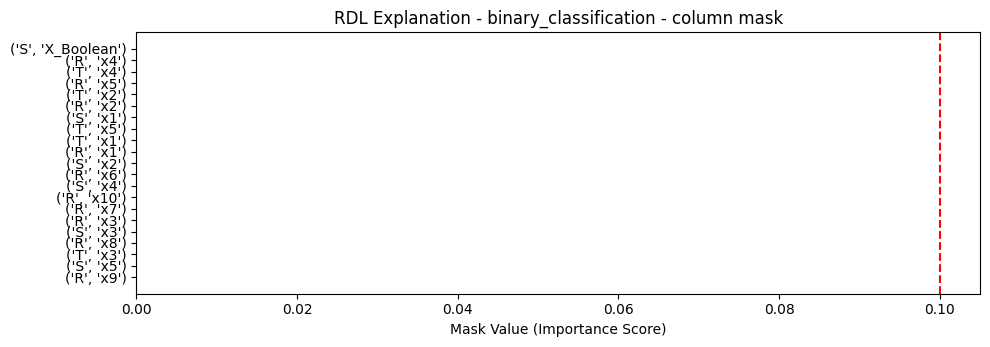

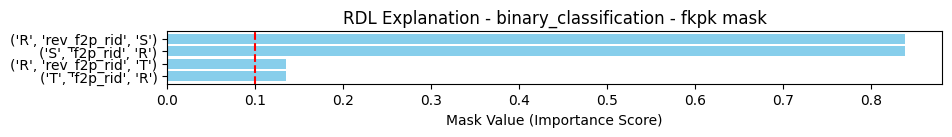

In [25]:
for mask_type in mask_types:
    print(f'Mask type: {mask_type}')
    mask = masks_all[mask_type]
    metrics = metrics_all[mask_type]

    # Prepare data for plotting
    explanation_elements = []
    importance_scores = []
    for explanation_element, mask_value in mask.items():
        explanation_elements.append(f'{explanation_element}')
        importance_scores.append(torch.sigmoid(mask_value).item())  # Apply sigmoid to get importance score between 0 and 1

    # Create a DataFrame for easier plotting
    importance_df = pd.DataFrame({
        'Explanation Element': explanation_elements,
        'Importance Score': importance_scores
    })
    # Sort the DataFrame by importance score
    importance_df = importance_df.sort_values(by='Importance Score', ascending=False)
    # show_top_k = True

    # Plotting
    plt.figure(figsize=(10, 0.17*len(importance_df)))
    plt.barh(importance_df['Explanation Element'], importance_df['Importance Score'], color='skyblue')
    plt.xlabel('Mask Value (Importance Score)')
    plt.title(f'RDL Explanation - {task_type} - {mask_type} mask')
    plt.gca().invert_yaxis()  # Invert y-axis to have the highest scores on top
    plt.axvline(x=0.1, color='red', linestyle='--', label='Threshold (0.1)')
    plt.tight_layout()
    plt.savefig(f'./eval_local/results_case_study/figs/r-s-synthetic/mask_values_{task_name}_{mask_type}_mask.png', dpi=300, bbox_inches='tight')